# S4 — Descriptives, Table 1, Bias Check, and Reviewer-Ready Plots

This notebook:
1) loads the S3 analysis dataset (`pcos_analysis.parquet` preferred),
2) produces Table 1 (baseline): TAI+ vs TAI− using primary exposure definition `tai_A`,
3) restricts baseline comparisons to rows with definable exposure,
4) produces a separate bias-check table:
   - anti-TPO measured vs not measured,
5) generates publication-oriented figures:
   - distributions of key thyroid/metabolic variables,
   - androgen-related markers by TAI group,
   - missingness summary plot,
6) exports tables and figures to project output folders.

Important:
- Table 1 is descriptive and should not be over-interpreted as inferential evidence.
- Primary inferential results will come from downstream regression models.

## Imports

In [ ]:
import json
import logging
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Config

In [ ]:
def load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def resolve_config_path() -> Path:
    candidates = [
        Path("/content/reports/config_snapshot.json"),
        Path("/mnt/data/config_snapshot.json"),
        Path("/content/config.json"),
        Path("/mnt/data/config.json"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "No config found. Expected config_snapshot.json or config.json in /content or /mnt/data."
    )

CONFIG_PATH = resolve_config_path()
CFG = load_json(CONFIG_PATH)

print("Loaded config:", str(CONFIG_PATH))

Loaded config: /content/config.json


## Directories and logging

In [ ]:
def ensure_dirs(cfg: dict) -> None:
    path_keys = [
        "output_dir",
        "intermediate_dir",
        "figures_dir",
        "tables_dir",
        "models_dir",
        "reports_dir",
        "qc_dir",
        "supplementary_dir",
    ]
    for key in path_keys:
        if key in cfg.get("paths", {}):
            Path(cfg["paths"][key]).mkdir(parents=True, exist_ok=True)

def setup_logging(cfg: dict) -> None:
    if not cfg.get("logging", {}).get("enabled", False):
        return

    root_logger = logging.getLogger()
    if root_logger.handlers:
        root_logger.setLevel(logging.INFO)
        return

    log_file = Path(cfg["logging"]["log_file"])
    log_file.parent.mkdir(parents=True, exist_ok=True)

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
        handlers=[
            logging.FileHandler(log_file, encoding="utf-8"),
            logging.StreamHandler(),
        ],
    )
    logging.info("Logging initialized in S4.")
    logging.info("Config loaded from: %s", str(CONFIG_PATH))

ensure_dirs(CFG)
setup_logging(CFG)

tables_dir = Path(CFG["paths"]["tables_dir"])
figures_dir = Path(CFG["paths"]["figures_dir"])
intermediate_dir = Path(CFG["paths"]["intermediate_dir"])
reports_dir = Path(CFG["paths"]["reports_dir"])

## Loading pcos_analysis

In [ ]:
def resolve_analysis_data_paths(cfg: dict) -> List[Path]:
    return [
        Path(cfg["paths"]["intermediate_dir"]) / "pcos_analysis.parquet",
        Path(cfg["paths"]["intermediate_dir"]) / "pcos_analysis.csv",
        Path("/content/pcos_analysis.parquet"),
        Path("/content/pcos_analysis.csv"),
        Path("/mnt/data/pcos_analysis.parquet"),
        Path("/mnt/data/pcos_analysis.csv"),
    ]

def load_analysis_dataset(cfg: dict) -> Tuple[pd.DataFrame, str]:
    candidates = resolve_analysis_data_paths(cfg)

    parquet_candidates = [p for p in candidates if p.suffix == ".parquet" and p.exists()]
    csv_candidates = [p for p in candidates if p.suffix == ".csv" and p.exists()]

    for p in parquet_candidates:
        try:
            df = pd.read_parquet(p)
            return df, str(p)
        except Exception as e:
            logging.warning("Failed to read parquet %s: %r", str(p), e)

    for p in csv_candidates:
        try:
            df = pd.read_csv(p)
            return df, str(p)
        except Exception as e:
            logging.warning("Failed to read csv %s: %r", str(p), e)

    raise FileNotFoundError(
        "Could not locate pcos_analysis.parquet or pcos_analysis.csv in configured/intermediate locations."
    )

df, source_used = load_analysis_dataset(CFG)

print("Loaded:", source_used)
print("Shape:", df.shape)
df.head(3)

Loaded: /content/pcos_analysis.parquet
Shape: (1300, 77)


,id,age,anti_tpo,anti_tg,tsh,ft4,ft3,tg,hdl,tc,...,analysis_primary_minimal,analysis_non_hdl_minimal,analysis_ogtt120_minimal,exposure_tai_A_defined,endpoint_primary_defined,endpoint_non_hdl_defined,endpoint_ogtt120_defined,analysis_primary_eligible,analysis_non_hdl_eligible,analysis_ogtt120_eligible
0,7611,25.0,13.8,NaN,0.969,1.20,NaN,116.0,56.6,188.0,...,True,True,True,True,True,True,True,True,True,True
1,8133,25.0,12.6,NaN,2.050,1.18,NaN,144.0,41.9,196.0,...,True,True,True,True,True,True,True,True,True,True
2,11028,25.0,150.0,NaN,2.500,1.29,NaN,35.8,62.7,133.0,...,True,True,True,True,True,True,True,True,True,True


## Helpers

In [ ]:
def _to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")

def _to_bool_nullable(s: pd.Series) -> pd.Series:
    out = pd.Series(np.nan, index=s.index, dtype="object")
    s_str = s.astype(str).str.lower()
    out.loc[s_str.isin(["true", "1"])] = True
    out.loc[s_str.isin(["false", "0"])] = False
    if s.dtype == bool:
        out = s.astype(object)
    return out

def median_iqr(s: pd.Series) -> str:
    x = _to_num(s).dropna()
    if x.empty:
        return "NA"
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    med = x.median()
    return f"{med:.3g} [{q1:.3g}, {q3:.3g}]"

def mean_sd_str(s: pd.Series) -> str:
    x = _to_num(s).dropna()
    if x.empty:
        return "NA"
    return f"{x.mean():.3g} ({x.std(ddof=1):.3g})"

def count_pct_true(s: pd.Series) -> str:
    sb = _to_bool_nullable(s)
    denom = int(sb.notna().sum())
    num = int((sb == True).sum())
    pct = (num / denom * 100) if denom > 0 else np.nan
    return f"{num}/{denom} ({pct:.1f}%)" if denom > 0 else "NA"

def smd_continuous(s: pd.Series, g: pd.Series) -> float:
    x = _to_num(s)
    x1 = x[g == "TAI+"].dropna()
    x0 = x[g == "TAI−"].dropna()
    if x1.empty or x0.empty:
        return np.nan
    m1, sd1 = float(x1.mean()), float(x1.std(ddof=1))
    m0, sd0 = float(x0.mean()), float(x0.std(ddof=1))
    denom_df = len(x1) + len(x0) - 2
    if denom_df <= 0:
        return np.nan
    sp = np.sqrt(((len(x1) - 1) * sd1**2 + (len(x0) - 1) * sd0**2) / denom_df)
    if sp == 0 or np.isnan(sp):
        return np.nan
    return (m1 - m0) / sp

def smd_binary(s: pd.Series, g: pd.Series) -> float:
    y = _to_bool_nullable(s)
    y1 = y[g == "TAI+"]
    y0 = y[g == "TAI−"]
    if y1.notna().sum() == 0 or y0.notna().sum() == 0:
        return np.nan
    p1 = float((y1 == True).mean())
    p0 = float((y0 == True).mean())
    p = (p1 + p0) / 2
    denom = np.sqrt(p * (1 - p))
    if denom == 0 or np.isnan(denom):
        return np.nan
    return (p1 - p0) / denom

def permutation_pvalue_median_diff(x1: np.ndarray, x0: np.ndarray, n_perm: int = 3000, seed: int = 123) -> float:
    rng = np.random.default_rng(seed)
    x1 = x1[~np.isnan(x1)]
    x0 = x0[~np.isnan(x0)]
    if len(x1) == 0 or len(x0) == 0:
        return np.nan
    obs = np.median(x1) - np.median(x0)
    pooled = np.concatenate([x1, x0]).copy()
    n1 = len(x1)
    cnt = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        d = np.median(pooled[:n1]) - np.median(pooled[n1:])
        if abs(d) >= abs(obs):
            cnt += 1
    return (cnt + 1) / (n_perm + 1)

def binary_event_counts(s: pd.Series) -> Tuple[int, int]:
    sb = _to_bool_nullable(s)
    return int((sb == True).sum()), int(sb.notna().sum())

## Cohort definition for Table 1

Primary modeling cohort is narrower than the Table 1 cohort from S04.


S04 describes all women with definable exposure (tai_A),
whereas S05 requires both definable exposure and definable primary endpoint.


This explicit distinction is intentional and supports transparent cohort flow reporting.

In [ ]:
EXPOSURE = "tai_A"
if EXPOSURE not in df.columns:
    raise KeyError(f"Exposure not found: {EXPOSURE}")

df_t1 = df.loc[df[EXPOSURE].notna()].copy()

df_t1["TAI_group"] = np.where(df_t1[EXPOSURE].astype(str).str.lower().isin(["true", "1"]), "TAI+", "TAI−")

n_total_t1 = len(df_t1)
n_tai_pos = int((df_t1["TAI_group"] == "TAI+").sum())
n_tai_neg = int((df_t1["TAI_group"] == "TAI−").sum())

print("Table 1 cohort size:", n_total_t1)
print("TAI+:", n_tai_pos)
print("TAI−:", n_tai_neg)

Table 1 cohort size: 1055
TAI+: 84
TAI−: 971


## Selection of variables for Table 1

In [ ]:
continuous_vars = [
    "age",
    "tsh",
    "anti_tpo",
    "tg",
    "hdl",
    "tc",
    "ldl",
    "tg_hdl_ratio",
    "non_hdl",
    "glu0",
    "glu120",
    "tt",
    "ft",
    "dheas",
    "andro",
    "amh",
    "lh",
    "fsh",
    "shbg",
]

binary_vars = [
    "ep_primary",
    "ep_non_hdl",
    "ep_ogtt120",
    "euthyroid_tsh_only",
]

continuous_vars = [v for v in continuous_vars if v in df_t1.columns]
binary_vars = [v for v in binary_vars if v in df_t1.columns]

print("Exposure:", EXPOSURE)
print("Continuous vars:", len(continuous_vars))
print("Binary vars:", len(binary_vars))

Exposure: tai_A
Continuous vars: 19
Binary vars: 4


## Table 1

Table 1 is descriptive and is based on women with definable primary exposure (tai_A).


Therefore, its denominator may differ slightly from the primary modeling cohort.


The primary regression cohort in S05 additionally requires a defined primary endpoint (TG/HDL > cutoff), so Table 1 n and primary model n are not expected to be identical.

In [ ]:
g = df_t1["TAI_group"]
rows = []

rows.append({
    "variable": "N_group",
    "type": "meta",
    "TAI+": str(n_tai_pos),
    "TAI−": str(n_tai_neg),
    "n_non_missing_TAI+": "",
    "n_non_missing_TAI−": "",
    "n_missing_total": "",
    "SMD": "",
    "p_value": "",
    "p_value_method": "",
})

for v in continuous_vars:
    x = _to_num(df_t1[v])
    x1 = x[g == "TAI+"].to_numpy()
    x0 = x[g == "TAI−"].to_numpy()

    p_perm = permutation_pvalue_median_diff(
        x1, x0, n_perm=3000, seed=int(CFG["project"]["random_seed"])
    )

    rows.append({
        "variable": v,
        "type": "continuous",
        "TAI+": median_iqr(df_t1.loc[g == "TAI+", v]),
        "TAI−": median_iqr(df_t1.loc[g == "TAI−", v]),
        "n_non_missing_TAI+": int(df_t1.loc[g == "TAI+", v].notna().sum()),
        "n_non_missing_TAI−": int(df_t1.loc[g == "TAI−", v].notna().sum()),
        "n_missing_total": int(df_t1[v].isna().sum()),
        "SMD": round(float(smd_continuous(df_t1[v], g)), 3) if pd.notna(smd_continuous(df_t1[v], g)) else np.nan,
        "p_value": p_perm,
        "p_value_method": "permutation_median_diff",
    })

for v in binary_vars:
    rows.append({
        "variable": v,
        "type": "binary",
        "TAI+": count_pct_true(df_t1.loc[g == "TAI+", v]),
        "TAI−": count_pct_true(df_t1.loc[g == "TAI−", v]),
        "n_non_missing_TAI+": int(df_t1.loc[g == "TAI+", v].notna().sum()),
        "n_non_missing_TAI−": int(df_t1.loc[g == "TAI−", v].notna().sum()),
        "n_missing_total": int(df_t1[v].isna().sum()),
        "SMD": round(float(smd_binary(df_t1[v], g)), 3) if pd.notna(smd_binary(df_t1[v], g)) else np.nan,
        "p_value": np.nan,
        "p_value_method": "not_reported_for_binary_descriptives",
    })

table1 = pd.DataFrame(rows)

out_table1 = tables_dir / "Table1_TAI_A_baseline.csv"
table1.to_csv(out_table1, index=False)

print("Saved Table 1:", out_table1)
table1.head(20)

Saved Table 1: /content/outputs/tables/Table1_TAI_A_baseline.csv


,variable,type,TAI+,TAI−,n_non_missing_TAI+,n_non_missing_TAI−,n_missing_total,SMD,p_value,p_value_method
0,N_group,meta,84,971,,,,,,
1,age,continuous,"22 [21, 23]","22 [20, 23]",84,971,0,0.103,1.0,permutation_median_diff
2,tsh,continuous,"2.4 [1.46, 3.52]","1.77 [1.27, 2.42]",84,970,1,0.896,0.000333,permutation_median_diff
3,anti_tpo,continuous,"129 [70.9, 261]","9.9 [9, 13]",84,971,0,4.247,0.000333,permutation_median_diff
4,tg,continuous,"75.3 [58.8, 103]","77 [58.9, 105]",84,969,2,-0.018,0.718427,permutation_median_diff
5,hdl,continuous,"56.6 [48, 66]","57.8 [48.6, 67.2]",84,969,2,-0.012,0.497168,permutation_median_diff
6,tc,continuous,"164 [137, 188]","164 [146, 185]",84,969,2,-0.048,0.947684,permutation_median_diff
7,ldl,continuous,"85.5 [68.7, 107]","87.9 [72, 106]",84,969,2,-0.043,0.559813,permutation_median_diff
8,tg_hdl_ratio,continuous,"1.24 [0.95, 2.22]","1.29 [0.904, 2]",84,969,2,0.048,0.669444,permutation_median_diff
9,non_hdl,continuous,"103 [81.9, 127]","104 [86.8, 125]",84,969,2,-0.043,0.677441,permutation_median_diff


Note:
Table 1 is based on women with definable primary exposure (`tai_A`), whereas downstream regression models may use slightly smaller cohorts because endpoint availability is also required.

## Help table: event counts by TAI

In [ ]:
event_rows = []

for v in ["ep_primary", "ep_non_hdl", "ep_ogtt120"]:
    if v not in df_t1.columns:
        continue

    for grp in ["TAI+", "TAI−"]:
        num, denom = binary_event_counts(df_t1.loc[df_t1["TAI_group"] == grp, v])
        pct = (num / denom * 100) if denom > 0 else np.nan
        event_rows.append({
            "endpoint": v,
            "group": grp,
            "n_events": num,
            "n_non_missing": denom,
            "pct_events": round(pct, 2) if denom > 0 else np.nan,
        })

event_counts_t1 = pd.DataFrame(event_rows)
event_counts_t1_path = tables_dir / "Table1_event_counts_by_TAI_A.csv"
event_counts_t1.to_csv(event_counts_t1_path, index=False)

print("Saved:", event_counts_t1_path)
event_counts_t1

Saved: /content/outputs/tables/Table1_event_counts_by_TAI_A.csv


,endpoint,group,n_events,n_non_missing,pct_events
0,ep_primary,TAI+,4,84,4.76
1,ep_primary,TAI−,66,969,6.81
2,ep_non_hdl,TAI+,19,84,22.62
3,ep_non_hdl,TAI−,205,969,21.16
4,ep_ogtt120,TAI+,14,79,17.72
5,ep_ogtt120,TAI−,142,956,14.85


## Bias check: anti-TPO measured vs not measured

In [ ]:
df_bc = df.copy()
df_bc["anti_tpo_measured"] = df_bc["anti_tpo"].notna()

bias_vars = [v for v in ["age", "tg", "hdl", "tc", "tg_hdl_ratio", "non_hdl", "glu0", "glu120", "tsh"] if v in df_bc.columns]

rows = []
for v in bias_vars:
    x = _to_num(df_bc[v])
    x1 = x[df_bc["anti_tpo_measured"] == True].to_numpy()
    x0 = x[df_bc["anti_tpo_measured"] == False].to_numpy()

    p_perm = permutation_pvalue_median_diff(
        x1, x0, n_perm=3000, seed=int(CFG["project"]["random_seed"])
    )

    g_bias = df_bc["anti_tpo_measured"].map({True: "measured", False: "not_measured"})

    rows.append({
        "variable": v,
        "measured": median_iqr(df_bc.loc[df_bc["anti_tpo_measured"] == True, v]),
        "not_measured": median_iqr(df_bc.loc[df_bc["anti_tpo_measured"] == False, v]),
        "n_non_missing_measured": int(df_bc.loc[df_bc["anti_tpo_measured"] == True, v].notna().sum()),
        "n_non_missing_not_measured": int(df_bc.loc[df_bc["anti_tpo_measured"] == False, v].notna().sum()),
        "n_missing_total": int(df_bc[v].isna().sum()),
        "SMD": round(float(smd_continuous(df_bc[v], g_bias.replace({"measured": "TAI+", "not_measured": "TAI−"}))), 3)
               if pd.notna(smd_continuous(df_bc[v], g_bias.replace({"measured": "TAI+", "not_measured": "TAI−"}))) else np.nan,
        "p_value": p_perm,
        "p_value_method": "permutation_median_diff",
    })

bias_table = pd.DataFrame(rows)
out_bias = tables_dir / "TableS_measured_vs_notmeasured_antiTPO.csv"
bias_table.to_csv(out_bias, index=False)

print("Saved bias check table:", out_bias)
bias_table

Saved bias check table: /content/outputs/tables/TableS_measured_vs_notmeasured_antiTPO.csv


,variable,measured,not_measured,n_non_missing_measured,n_non_missing_not_measured,n_missing_total,SMD,p_value,p_value_method
0,age,"22 [20, 23]","18 [18, 19]",1055,245,0,1.684,0.000333,permutation_median_diff
1,tg,"76.8 [58.9, 105]","81 [60, 108]",1053,130,117,-0.089,0.272909,permutation_median_diff
2,hdl,"57.7 [48.6, 67.1]","52 [45, 57.8]",1053,130,117,0.455,0.000333,permutation_median_diff
3,tc,"164 [146, 185]","168 [148, 191]",1053,130,117,-0.207,0.284572,permutation_median_diff
4,tg_hdl_ratio,"1.28 [0.906, 2]","1.49 [1.07, 2.14]",1053,130,117,-0.175,0.024658,permutation_median_diff
5,non_hdl,"104 [86.5, 126]","118 [97.2, 135]",1053,130,117,-0.420,0.000666,permutation_median_diff
6,glu0,"83.8 [80.3, 88]","85 [80, 88.5]",1036,127,137,-0.016,0.077308,permutation_median_diff
7,glu120,"107 [91.4, 127]","105 [90, 118]",1035,127,138,0.230,0.549484,permutation_median_diff
8,tsh,"1.79 [1.28, 2.47]","2.18 [1.62, 2.85]",1054,128,118,-0.382,0.000333,permutation_median_diff


## Figure 1: Distributions of key variables

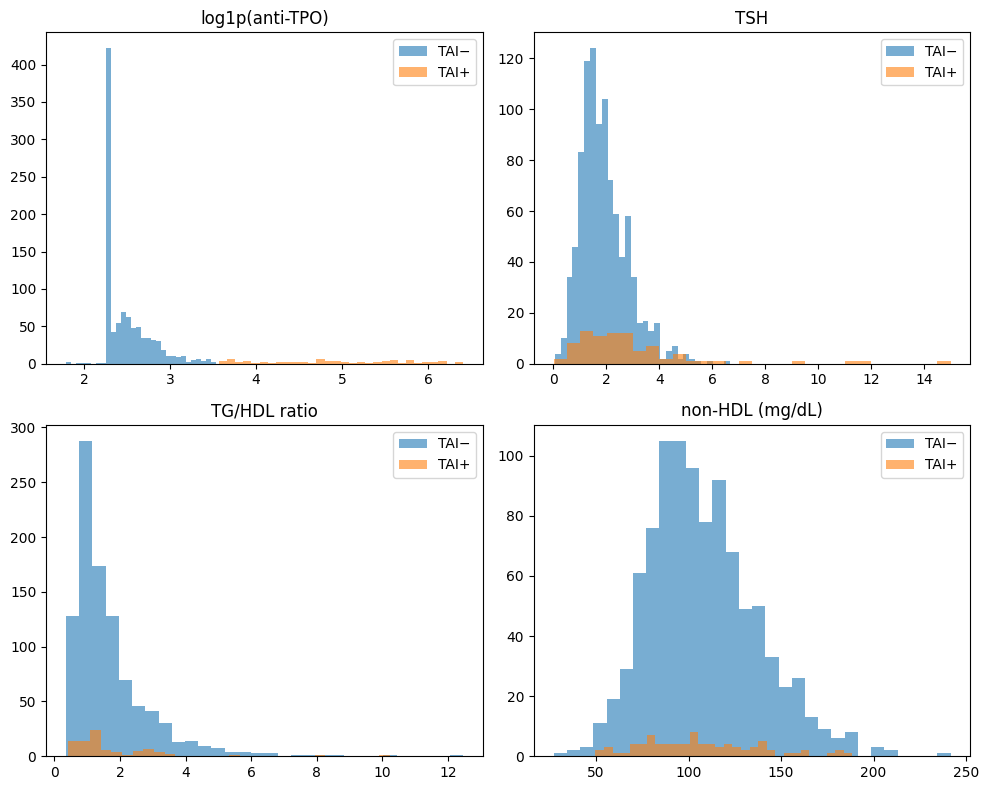

Saved: /content/outputs/figures/F1_distributions_TAI_A.png


In [ ]:
vars_dist = []
if "log1p_anti_tpo" in df_t1.columns:
    vars_dist.append(("log1p_anti_tpo", "log1p(anti-TPO)"))
elif "anti_tpo" in df_t1.columns:
    vars_dist.append(("anti_tpo", "anti-TPO"))

if "tsh" in df_t1.columns:
    vars_dist.append(("tsh", "TSH"))

if "tg_hdl_ratio" in df_t1.columns:
    vars_dist.append(("tg_hdl_ratio", "TG/HDL ratio"))

if "non_hdl" in df_t1.columns:
    vars_dist.append(("non_hdl", "non-HDL (mg/dL)"))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (col, title) in enumerate(vars_dist[:4]):
    x_pos = _to_num(df_t1.loc[df_t1["TAI_group"] == "TAI+", col]).dropna()
    x_neg = _to_num(df_t1.loc[df_t1["TAI_group"] == "TAI−", col]).dropna()

    axes[i].hist(x_neg, bins=30, alpha=0.6, label="TAI−")
    axes[i].hist(x_pos, bins=30, alpha=0.6, label="TAI+")
    axes[i].set_title(title)
    axes[i].legend()

for j in range(len(vars_dist[:4]), 4):
    axes[j].axis("off")

plt.tight_layout()
out_f1 = figures_dir / "F1_distributions_TAI_A.png"
plt.savefig(out_f1, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_f1)

## Figure 2: androgens according to TAI

/tmp/ipykernel_298/1612838712.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x_neg, x_pos], labels=["TAI−", "TAI+"], showfliers=False)
/tmp/ipykernel_298/1612838712.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x_neg, x_pos], labels=["TAI−", "TAI+"], showfliers=False)
/tmp/ipykernel_298/1612838712.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([x_neg, x_pos], labels=["TAI−", "TAI+"], showfliers=False)
/tmp/ipykernel_298/1612838712.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support fo

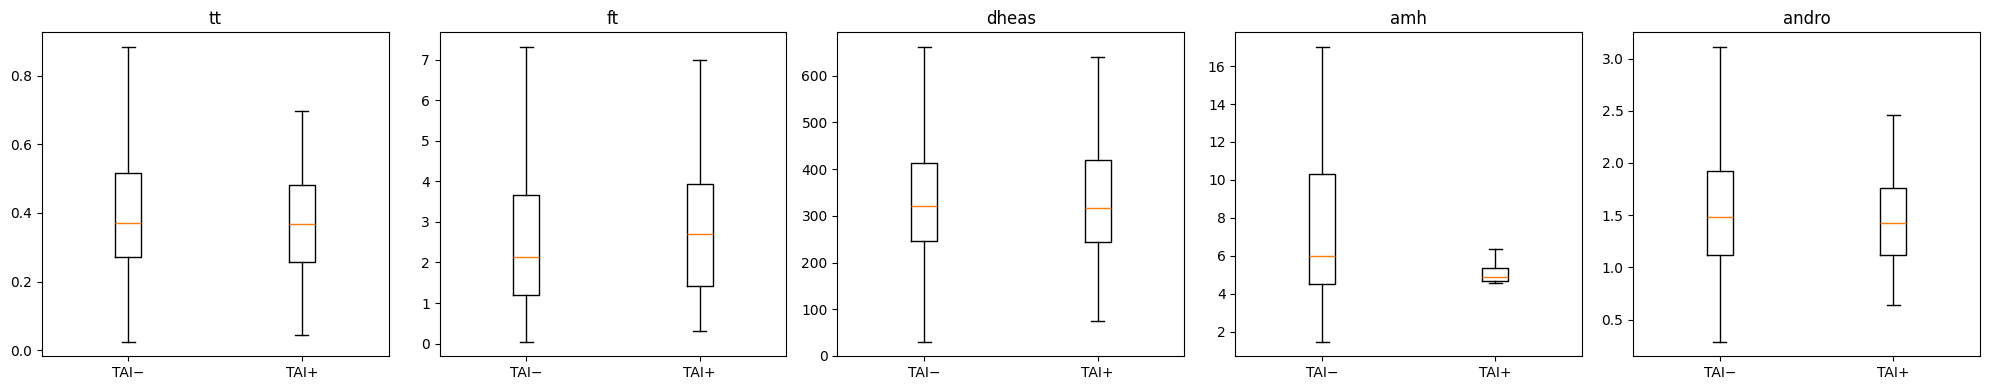

Saved: /content/outputs/figures/F2_androgens_by_TAI_A.png


In [ ]:
androgen_vars = [v for v in ["tt", "ft", "dheas", "amh", "andro"] if v in df_t1.columns]

if len(androgen_vars) == 0:
    print("No androgen variables found to plot.")
else:
    fig, axes = plt.subplots(1, len(androgen_vars), figsize=(4 * len(androgen_vars), 4))
    if len(androgen_vars) == 1:
        axes = [axes]

    for ax, v in zip(axes, androgen_vars):
        x_neg = _to_num(df_t1.loc[df_t1["TAI_group"] == "TAI−", v]).dropna()
        x_pos = _to_num(df_t1.loc[df_t1["TAI_group"] == "TAI+", v]).dropna()

        ax.boxplot([x_neg, x_pos], labels=["TAI−", "TAI+"], showfliers=False)
        ax.set_title(v)

    plt.tight_layout()
    out_f2 = figures_dir / "F2_androgens_by_TAI_A.png"
    plt.savefig(out_f2, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", out_f2)

## Figure 3: missingness barplot

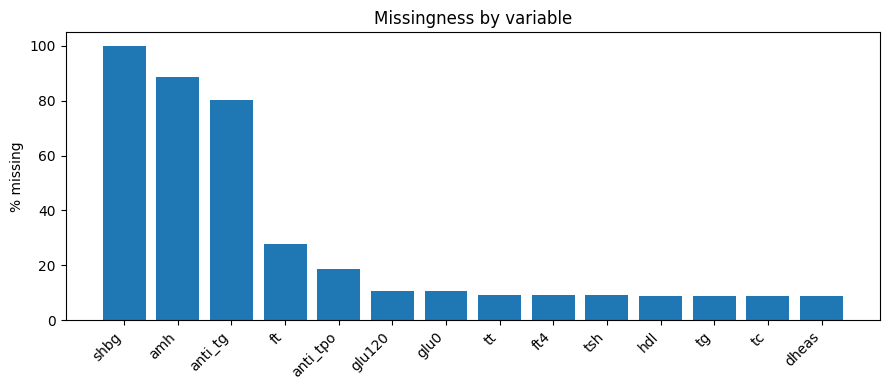

Saved: /content/outputs/figures/F3_missingness_barplot.png


,0
shbg,99.923077
amh,88.692308
anti_tg,80.230769
ft,27.846154
anti_tpo,18.846154
glu120,10.615385
glu0,10.538462
tt,9.153846
ft4,9.153846
tsh,9.076923


In [ ]:
heat_vars = [
    v for v in [
        "anti_tpo", "tsh", "anti_tg", "ft4", "tg", "hdl", "tc",
        "glu0", "glu120", "tt", "ft", "dheas", "amh", "shbg"
    ] if v in df.columns
]

miss_pct = (df[heat_vars].isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
plt.bar(range(len(miss_pct)), miss_pct.values)
plt.xticks(range(len(miss_pct)), miss_pct.index, rotation=45, ha="right")
plt.ylabel("% missing")
plt.title("Missingness by variable")
plt.tight_layout()

out_f3 = figures_dir / "F3_missingness_barplot.png"
plt.savefig(out_f3, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_f3)
miss_pct

## Summary JSON

In [ ]:
summary = {
    "source_used": source_used,
    "n_rows_total": int(len(df)),
    "n_rows_table1_exposure_defined": int(len(df_t1)),
    "n_tai_pos": int(n_tai_pos),
    "n_tai_neg": int(n_tai_neg),
    "exposure": EXPOSURE,
    "continuous_vars_in_table1": continuous_vars,
    "binary_vars_in_table1": binary_vars,
}

summary_path = reports_dir / "s4_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved:", summary_path)
summary

Saved: /content/reports/s4_summary.json


{'source_used': '/content/pcos_analysis.parquet',
 'n_rows_total': 1300,
 'n_rows_table1_exposure_defined': 1055,
 'n_tai_pos': 84,
 'n_tai_neg': 971,
 'exposure': 'tai_A',
 'continuous_vars_in_table1': ['age',
  'tsh',
  'anti_tpo',
  'tg',
  'hdl',
  'tc',
  'ldl',
  'tg_hdl_ratio',
  'non_hdl',
  'glu0',
  'glu120',
  'tt',
  'ft',
  'dheas',
  'andro',
  'amh',
  'lh',
  'fsh',
  'shbg'],
 'binary_vars_in_table1': ['ep_primary',
  'ep_non_hdl',
  'ep_ogtt120',
  'euthyroid_tsh_only']}

## Checklist

## S4 completion checklist

- [ ] Review `Table1_TAI_A_baseline.csv`.
- [ ] Review `Table1_event_counts_by_TAI_A.csv`.
- [ ] Review `TableS_measured_vs_notmeasured_antiTPO.csv`.
- [ ] Inspect `F1_distributions_TAI_A.png`.
- [ ] Inspect `F2_androgens_by_TAI_A.png`.
- [ ] Inspect `F3_missingness_barplot.png`.
- [ ] Proceed to S5 (primary model).|